In [1]:
# Wolfram Language Imports
try:
    ws
except NameError:
    ws = None

if ws != None:
    print('Stopping existing wolfram session.')
    ws.stop()

from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [7]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    fig, ax = plt.subplots(figsize=(7, 5))
    img = mpimg.imread(filename)
    ax.imshow(img)
    ax.axis('off')
    

## Evaluate Legendre Approximations

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


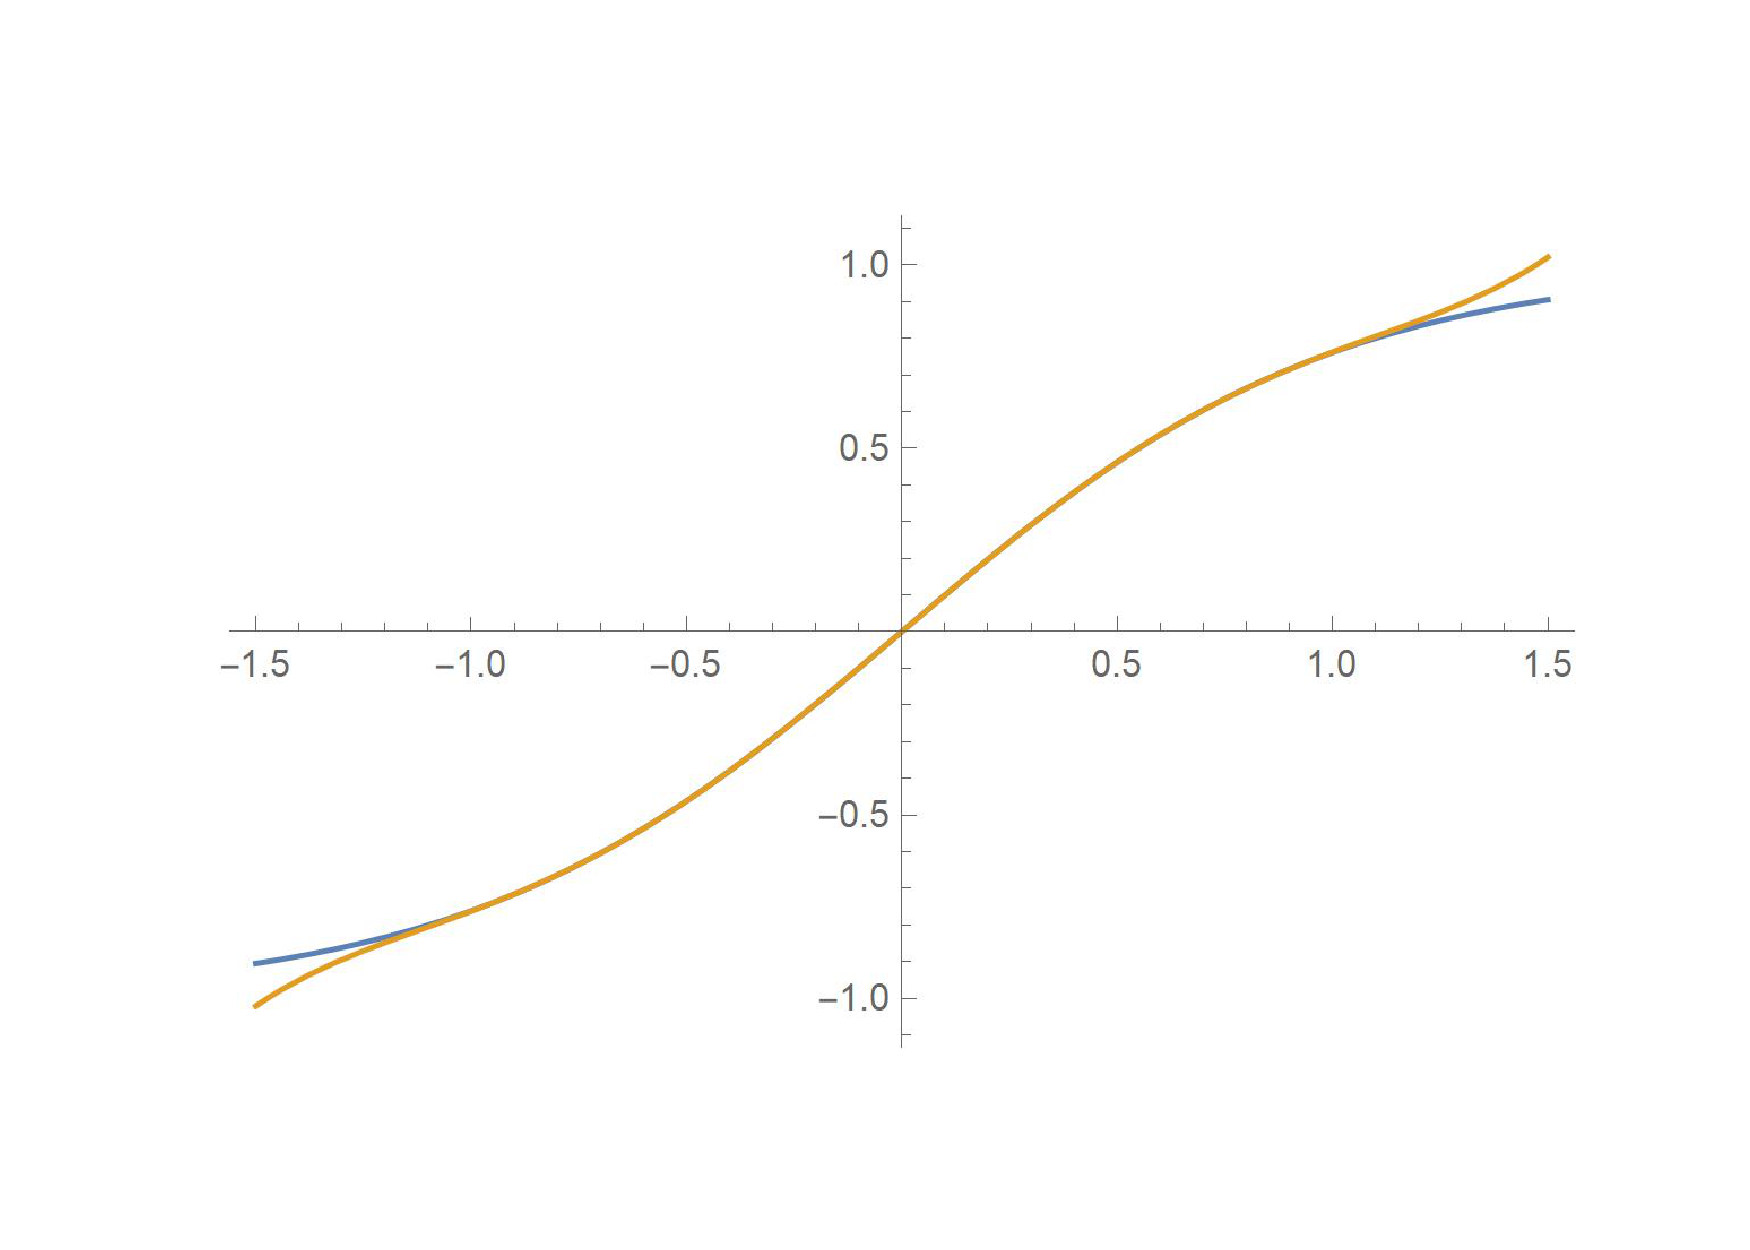

In [5]:
wplot("tanh_legendre.jpg", 
'''
rrr = Table[(n + 1/2) Integrate[LegendreP[n, x] Tanh[x], {x, -1, 1}], {n, 0, 5}];
Plot[ {Tanh[x], rrr.Table[LegendreP[n - 1, x], {n, Length[rrr]}]}, {x, -1.5, 1.5}]
''')


<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


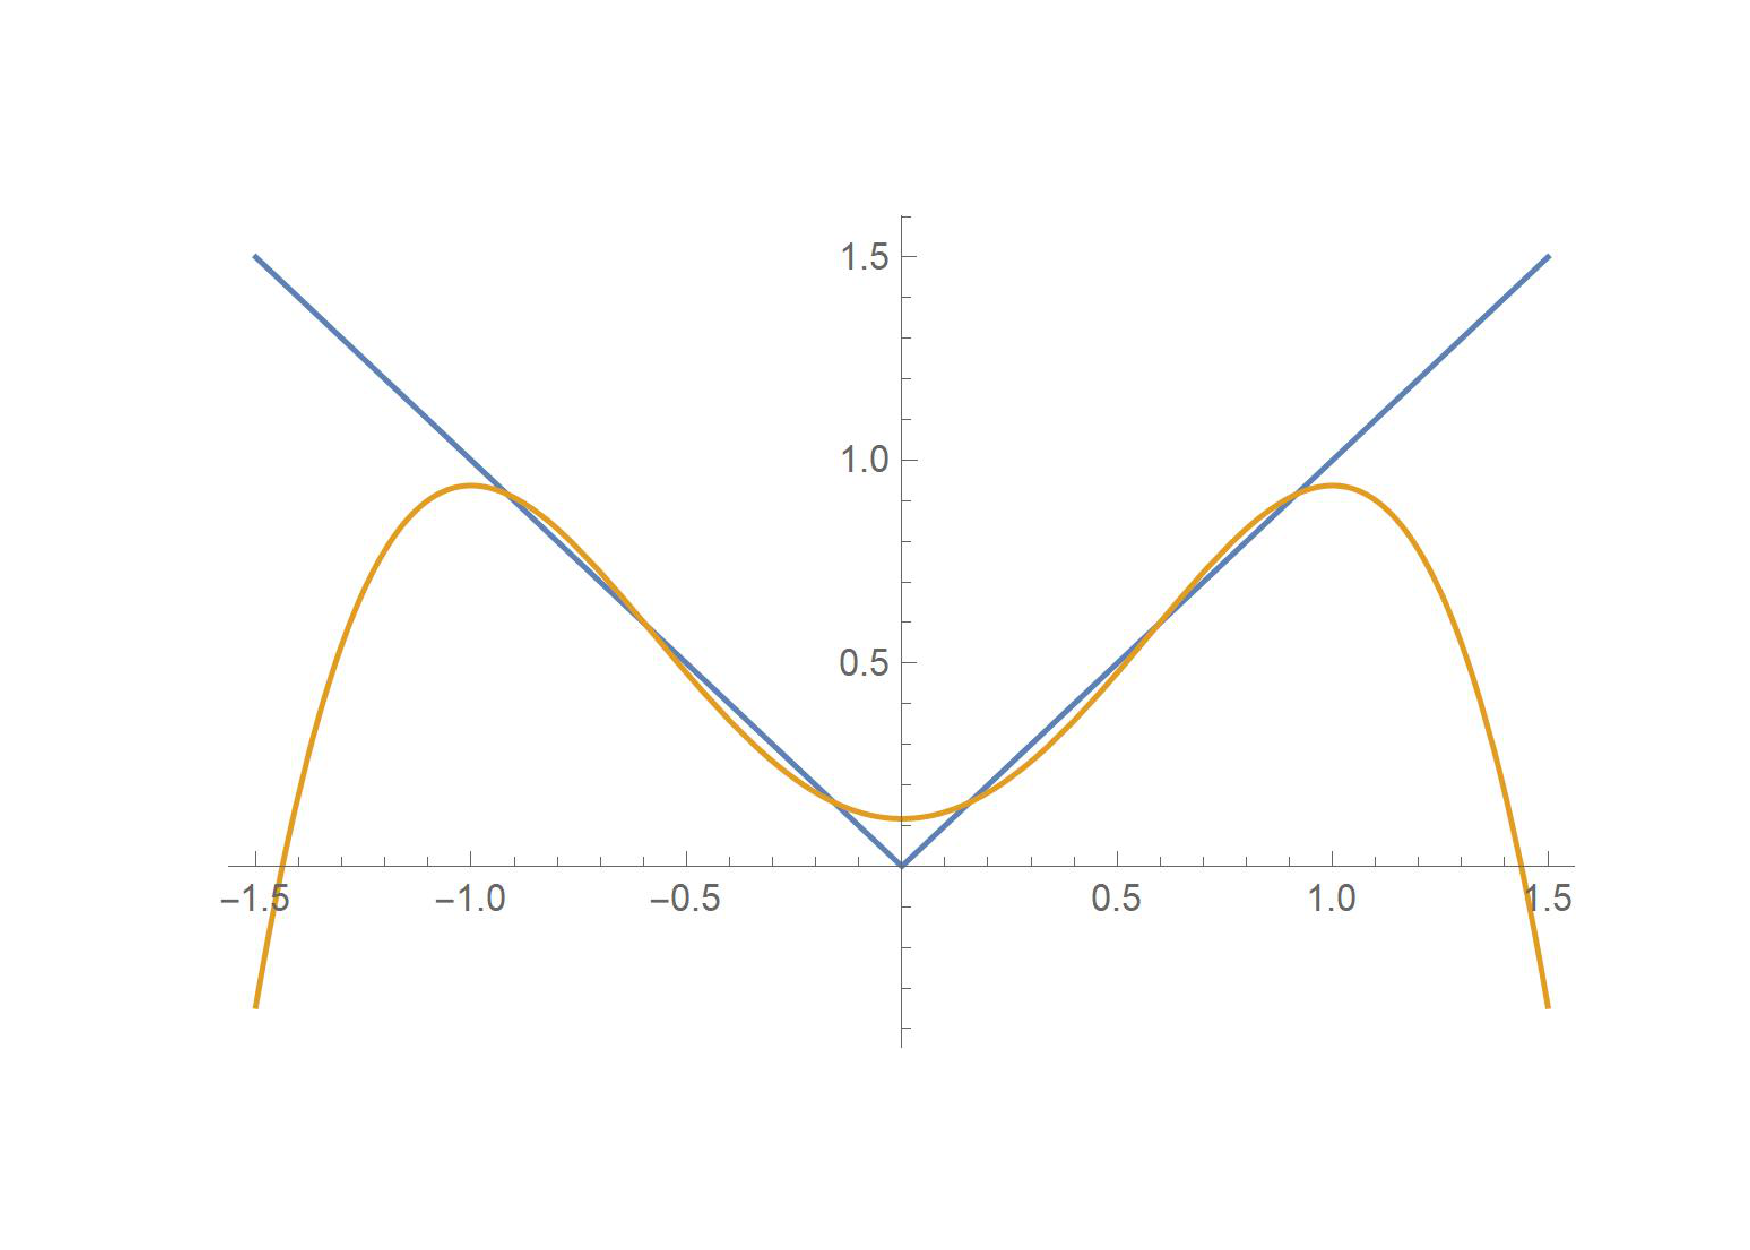

In [6]:
wplot("abs_legendre.jpg", 
'''
rrr = Table[(n + 1/2) Integrate[LegendreP[n, x] Abs[x], {x, -1, 1}], {n, 0, 5}];
Plot[ {Abs[x], rrr.Table[LegendreP[n - 1, x], {n, Length[rrr]}]}, {x, -1.5, 1.5}]
''')

In [53]:
wc('''
rrr = Table[
2/Pi NIntegrate[Tanh[x] ChebyshevT[n, x] / Sqrt[1 - x^2], {x, -1, 1}],
{n, 0, 10}]
''')

<IPython.core.display.Math object>

(0.0,
 0.8116756851315633,
 0.0,
 -0.054245810326256375,
 0.0,
 0.004516821992838887,
 0.0,
 -0.00038244717056547153,
 0.0,
 3.244394844690185e-05,
 0.0)

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


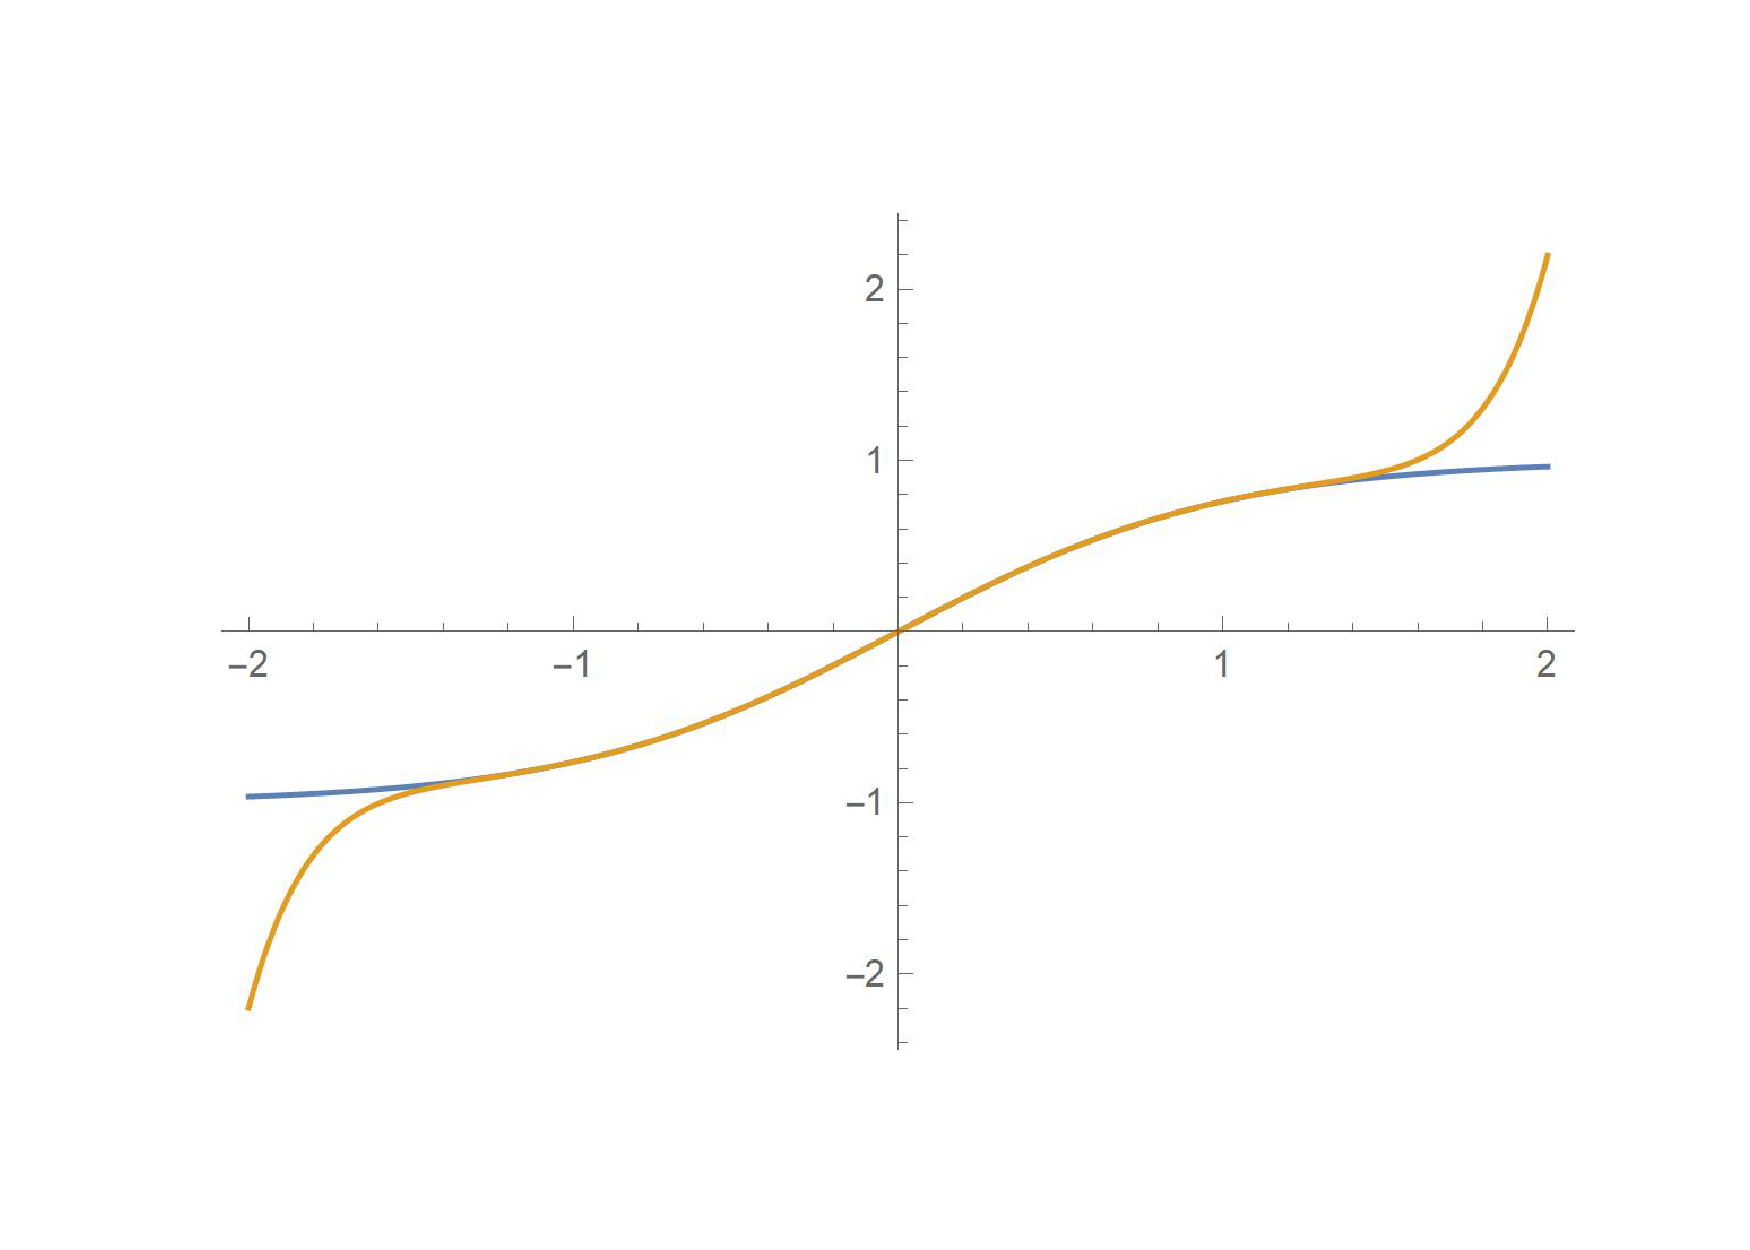

In [54]:
wplot('tanh_chebyshev.jpg',
'''Plot[
{Tanh[x], Evaluate[-First[rrr]/2 + rrr.Table[ChebyshevT[n - 1, x], {n, Length[rrr]}]]}, {x, -2, 2}]
''')

In [55]:
wc('''
rrr = Table[
2/Pi NIntegrate[Abs[x] ChebyshevT[n, x] / Sqrt[1 - x^2], {x, -1, 1}],
{n, 0, 10}]
''')

<IPython.core.display.Math object>

(1.27323954473517,
 0.0,
 0.4244131815783879,
 -6.339022177639093e-16,
 -0.08488263631567763,
 -6.593024808450415e-16,
 0.036378272706719075,
 5.709537396932771e-16,
 -0.020210151503733138,
 3.810039462169838e-16,
 0.012861005502363732)

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


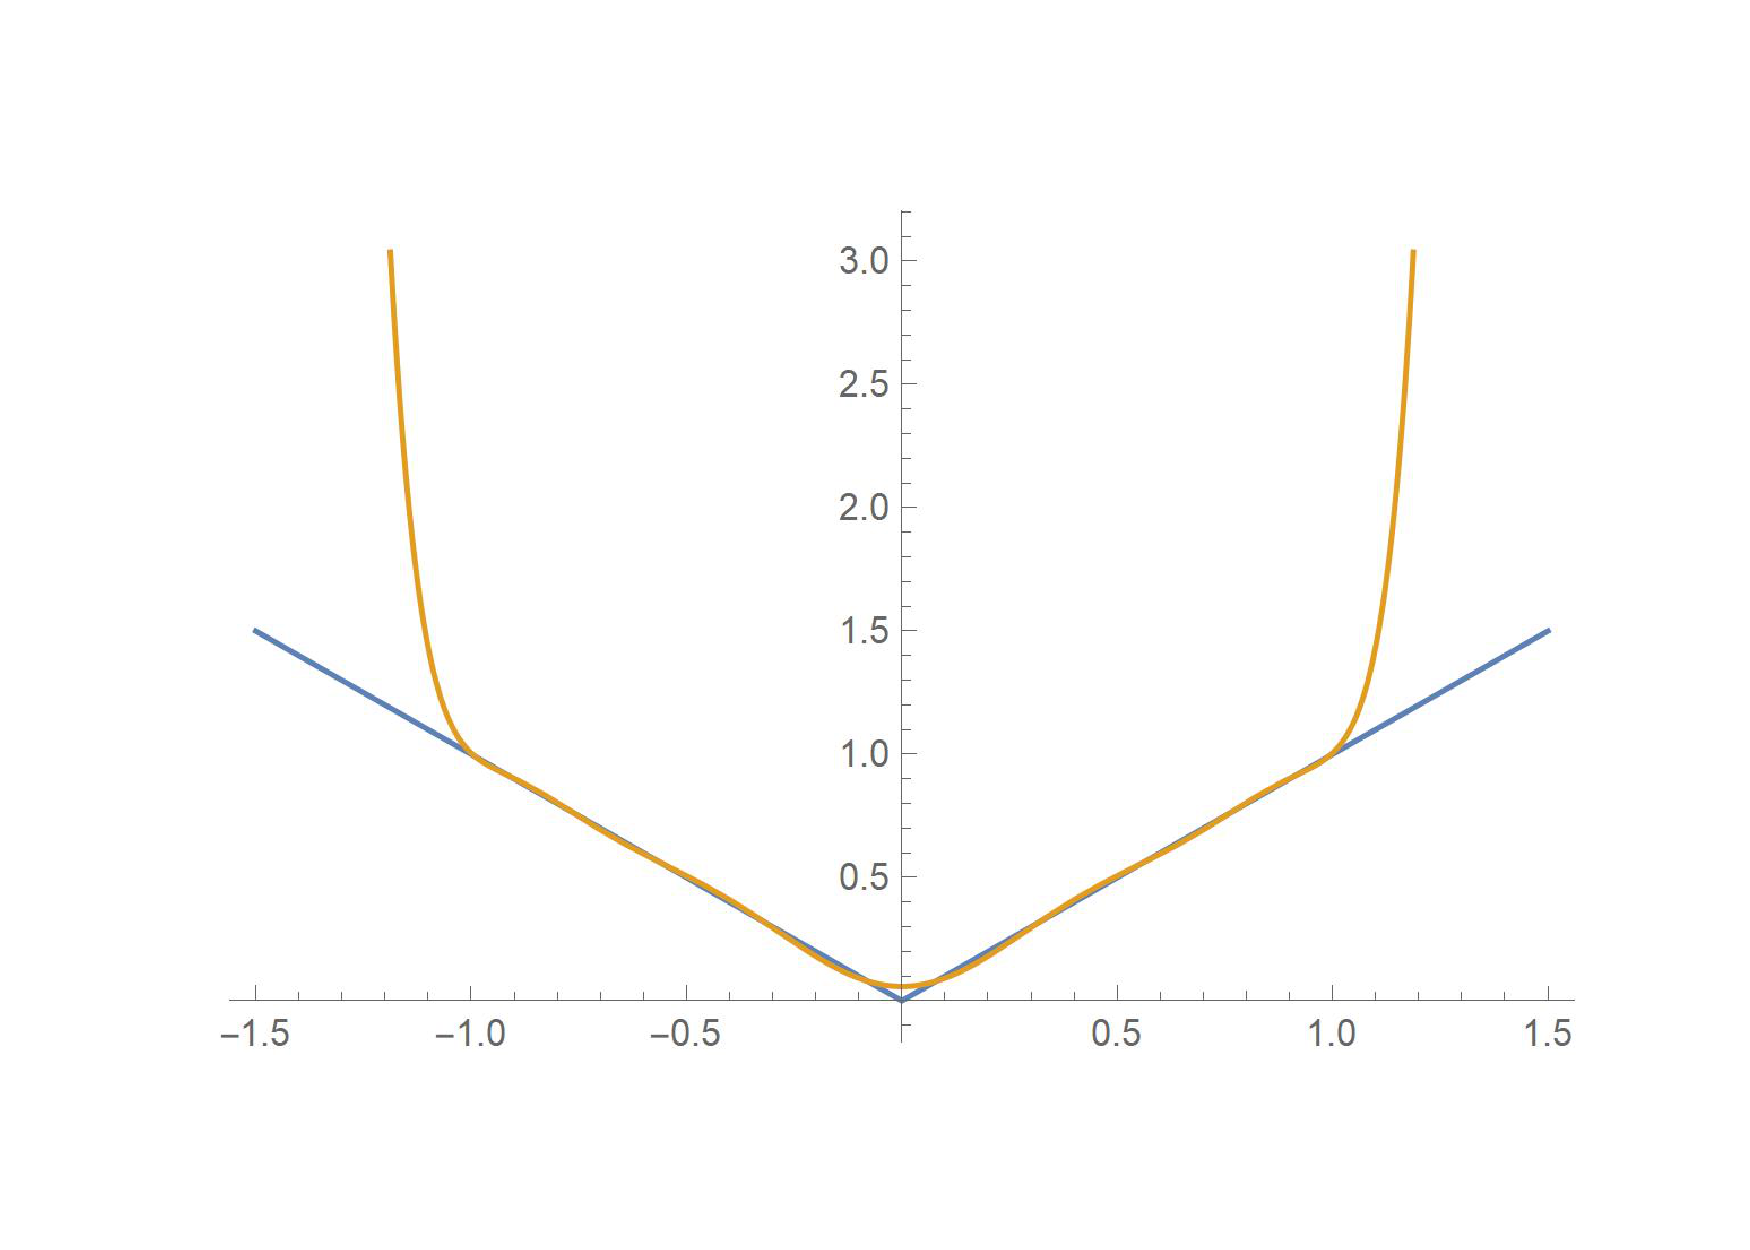

In [56]:
wplot('abs_chebyshev.jpg',
'''Plot[
{Abs[x], Evaluate[-First[rrr]/2 + rrr.Table[ChebyshevT[n - 1, x], {n, Length[rrr]}]]}, {x, -1.5, 1.5}]
''')

In [ ]:
ws.stop()